In [36]:
import sunpy
import sunpy.map
import numpy as np
from math import *
import astropy.units as u
from astropy.io import fits
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sunpy.coordinates import frames
import matplotlib.gridspec as gridspec
from scipy.interpolate import interp1d
from astropy.coordinates import SkyCoord
from matplotlib.patches import ConnectionPatch
import os,cv2
from scipy.optimize import fmin
from scipy.ndimage import affine_transform
import shutil
from scipy.io import readsav
import glob
from matplotlib.patches import Rectangle
from scipy.ndimage import zoom
from matplotlib.colors import Normalize,LogNorm
import matplotlib.ticker as ticker

In [11]:
#这里dir1是pre_131.sav的目录对应0-31，dir2是131.sav的目录对应32-132，exptime是长148的观测时间
def aia_intensity_curve(dir1,dir2,dir3,exptime,wavelenth):
    from scipy.io import readsav
    #这部分先把数据读入进来
    matrices=[]
    data1=readsav(dir1)
    matrix_struct=data1['matrix_struct']
    for i,entry in enumerate(matrix_struct):
        matrix=entry['matrix']
        matrices.append(matrix)
    matrices=matrices[69:]#这一步是当时我matrices统一设置成大小为110了，所以存的数据都在后面
    data2=readsav(dir2)
    matrix_struct=data2['matrix_struct']
    for i,entry in enumerate(matrix_struct):
        matrix=entry['matrix']
        matrices.append(matrix)
    data3=readsav(dir3)
    matrix_struct=data3['matrix_struct']
    for i,entry in enumerate(matrix_struct):
        matrix=entry['matrix']
        matrices.append(matrix)
    #计算平均强度
    intensity=np.zeros(148)
    for i in range(148):
        intensity[i]=np.average(matrices[i])
    #这里去掉曝光时间不一致的点，131和193单独处理
    if wavelenth=='131' or '193':
        threshold=2.90 if wavelenth=='131' else 1.99
        #print(threshold)
        intensity[exptime[:]<threshold]=np.nan
        #把去掉的点用插值函数补上
        x=np.arange(148)
        valid_x=x[~np.isnan(intensity)]
        valid_intensity=intensity[~np.isnan(intensity)]
        f=interp1d(valid_x,valid_intensity,kind='linear')
        intensity[np.isnan(intensity)]=f(x[np.isnan(intensity)])
    #归一化
    intensity=(intensity-np.min(intensity))/(np.max(intensity)-np.min(intensity))
    return intensity

In [12]:
intensity=np.zeros((7,148))
name_list=['.94','131','171','193','211','304','335']

for i in range(7):
    file_list=glob.glob(r'D:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\\'+name_list[i]+'\*.fits')
    exptime=np.zeros(len(file_list))
    for j in range(len(file_list)):
        rsm=fits.open(file_list[j])
        exptime[j]=rsm[1].header['EXPTIME']

    dir1=r'D:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\pre_'+name_list[i]+'.sav'
    dir2=r'D:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\\'+name_list[i]+'.sav'
    dir3=r'D:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\post_'+name_list[i]+'.sav'
    intensity[i,:]=aia_intensity_curve(dir1,dir2,dir3,exptime[:],name_list[i])
    #print(exptime[:133])

In [4]:
map1=sunpy.map.Map(r'D:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\131\aia.lev1_euv_12s.2024-06-18T210908Z.131.image_lev1.fits')
map2=sunpy.map.Map(r'D:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\131\aia.lev1_euv_12s.2024-06-18T211344Z.131.image_lev1.fits')
map3=sunpy.map.Map(r'D:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\131\aia.lev1_euv_12s.2024-06-18T211820Z.131.image_lev1.fits')
map4=sunpy.map.Map(r'D:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\131\aia.lev1_euv_12s.2024-06-18T212244Z.131.image_lev1.fits')
map5=sunpy.map.Map(r'D:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\131\aia.lev1_euv_12s.2024-06-18T212620Z.131.image_lev1.fits')
map6=sunpy.map.Map(r'D:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\171\aia.lev1_euv_12s.2024-06-18T211822Z.171.image_lev1.fits')

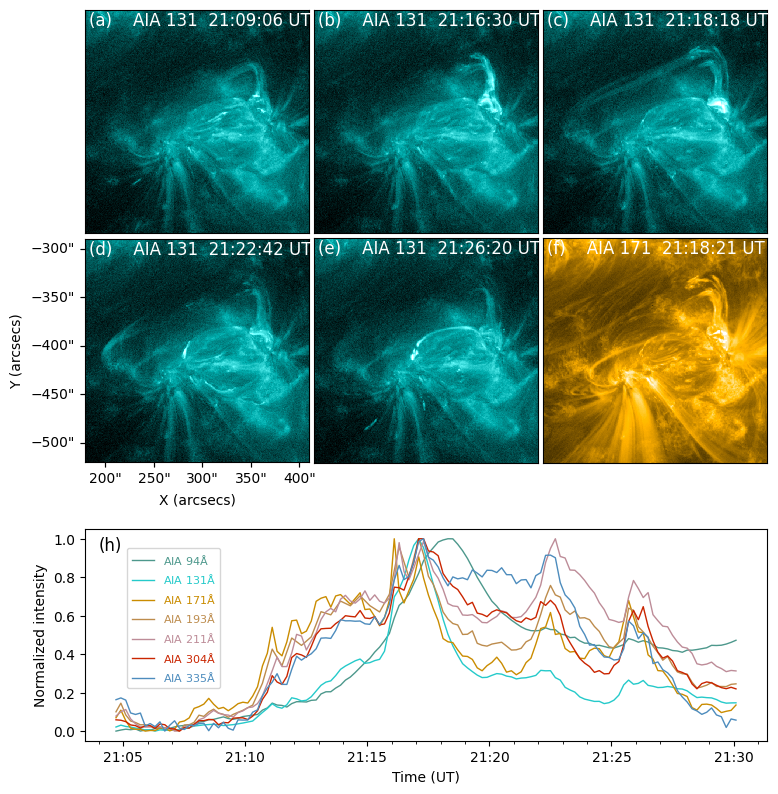

In [22]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(8.8,9.5))

# 整体划分为上下两大块：上(3份高度)，下(2份高度)
gs = gridspec.GridSpec(2, 1, height_ratios=[7.5, 3.5], hspace=0.2)

# ---------------- 上半部分：AIA 三幅图 ----------------
# 这里再细分成 1 行 3 列的小网格
gs_top = gridspec.GridSpecFromSubplotSpec(2, 3, subplot_spec=gs[0], wspace=0.02,hspace=0.02)
bottom_left=SkyCoord(Tx=180*u.arcsec,Ty=-520*u.arcsec,frame=map1.coordinate_frame)
top_right=SkyCoord(Tx=410*u.arcsec,Ty=-290*u.arcsec,frame=map1.coordinate_frame)

map_all=[map1,map2,map3,map4,map5,map6]
smap_all=[]
for i in map_all:
    smap_all.append(i.submap(bottom_left,top_right=top_right))

ax_all=[]
for i in range(6):
    ax=fig.add_subplot(gs_top[i],projection=smap_all[i])
    ax_all.append(ax)
    #smap_all[i].plot(axes=ax)
    if i!=5:
        old_norm=smap_all[i].plot_settings['norm']
        old_norm.vmin=0.01
        old_norm.vmax=2000
        smap_all[i].plot(axes=ax,norm=old_norm)
    else:
        old_norm=smap_all[i].plot_settings['norm']
        old_norm.vmin=0.01
        old_norm.vmax=5000
        smap_all[i].plot(axes=ax,norm=old_norm)
    ax.set_title('')
    ax.coords[0].grid(draw_grid=False)
    ax.coords[1].grid(draw_grid=False)
    #第四张图加X Y轴
    if i == 3:   # 左下角
        #非常搞，如果不加这个labelpad就会在x轴上方出现一条小缝
        ax.set_xlabel('X (arcsecs)')
        ax.set_ylabel('Y (arcsecs)')
        ax.tick_params(axis='x',which='both',bottom=True,labelbottom=True,top=False,labeltop=False)
        ax.tick_params(axis='y',which='both',left=True,labelleft=True,right=False,labelright=False)       
    else:
        ax.coords[0].set_ticklabel_visible(False)
        ax.coords[1].set_ticklabel_visible(False)
        ax.coords[0].set_ticks_visible(False)
        ax.coords[1].set_ticks_visible(False)

ax_all[0].text(0.02,0.93,'(a)    AIA 131  21:09:06 UT',color='white',transform=ax_all[0].transAxes,fontsize=12)
ax_all[1].text(0.02,0.93,'(b)    AIA 131  21:16:30 UT',color='white',transform=ax_all[1].transAxes,fontsize=12)
ax_all[2].text(0.02,0.93,'(c)    AIA 131  21:18:18 UT',color='white',transform=ax_all[2].transAxes,fontsize=12)
ax_all[3].text(0.02,0.93,'(d)    AIA 131  21:22:42 UT',color='white',transform=ax_all[3].transAxes,fontsize=12)
ax_all[4].text(0.02,0.93,'(e)    AIA 131  21:26:20 UT',color='white',transform=ax_all[4].transAxes,fontsize=12)
ax_all[5].text(0.02,0.93,'(f)    AIA 171  21:18:21 UT',color='white',transform=ax_all[5].transAxes,fontsize=12)

# ---------------- 下半部分：两行共享x轴 ----------------
gs_bottom = gridspec.GridSpecFromSubplotSpec(1, 1, subplot_spec=gs[1], hspace=0.05)

ax8 = fig.add_subplot(gs_bottom[0])

name_list=['AIA 94$\mathrm{\AA}$','AIA 131$\mathrm{\AA}$',
           'AIA 171$\mathrm{\AA}$','AIA 193$\mathrm{\AA}$',
           'AIA 211$\mathrm{\AA}$','AIA 304$\mathrm{\AA}$','AIA 335$\mathrm{\AA}$']
lines=[]
linstyle=['-','-']

#从AIA那几个波段的cmap里采集颜色用来画曲线
color=[]
color_list=['sdoaia94','sdoaia131','sdoaia171','sdoaia193','sdoaia211','sdoaia304','sdoaia335']
for i in range(7):
    cmap=plt.get_cmap(color_list[i])
    middle_color=cmap(0.55)
    color.append(middle_color)
#画七条AIA曲线
for i in range(7):
    line,=ax8.plot(intensity[i,20:],color=color[i],label=name_list[i],linewidth=1,linestyle=linstyle[i%2])
    lines.append(line)
legend=ax8.legend(loc='center', bbox_to_anchor=(0.13, 0.58),fontsize=8)
#让legend里的文字颜色和曲线颜色一致
for text,line in zip(legend.get_texts(),lines):
    text.set_color(line.get_color())

corr_x=np.zeros(6)
#第一个时刻对应21：00：42，最后一个时刻对应21：27：06
for i in range(len(corr_x)):
    corr_x[i]=(i*300+18)/12
ax8.set_ylabel('Normalized intensity')
ax8.set_xticks(ticks=corr_x,labels=['21:05','21:10','21:15','21:20','21:25','21:30'])
ax8.text(0.02,0.9,'(h)',color='black',transform=ax8.transAxes,fontsize=12)
import matplotlib.ticker as ticker
ax8.xaxis.set_minor_locator(ticker.AutoMinorLocator())  # 给 x 轴加小刻度
ax8.yaxis.set_minor_locator(ticker.NullLocator())       # 禁止 y 轴小刻度
ax8.set_xlabel('Time (UT)')
plt.savefig(r'D:\Learning\PHD1st\magnetic_reconnecion\paper\fig2\aia_image_intensity_curve.pdf',format='pdf',bbox_inches='tight', pad_inches=0.1)

IRIS

In [23]:
all_sji_image=readsav(r'D:\Learning\PHD1st\magnetic_reconnecion\data_process\all_sji_image.sav')['matrix_struct']
data=np.load(r'D:\Learning\PHD1st\magnetic_reconnecion\data_process\doppler_sigma_vel_nonth.npz')
doppler_vel_all=data['doppler_vel_all']
sigma_vel_nonth=data['sigma_vel_nonth']
vel_all2 = np.load(r'D:\Learning\PHD1st\magnetic_reconnecion\data_process\vel_all.npy', allow_pickle=True)
vel_all=vel_all2.item()

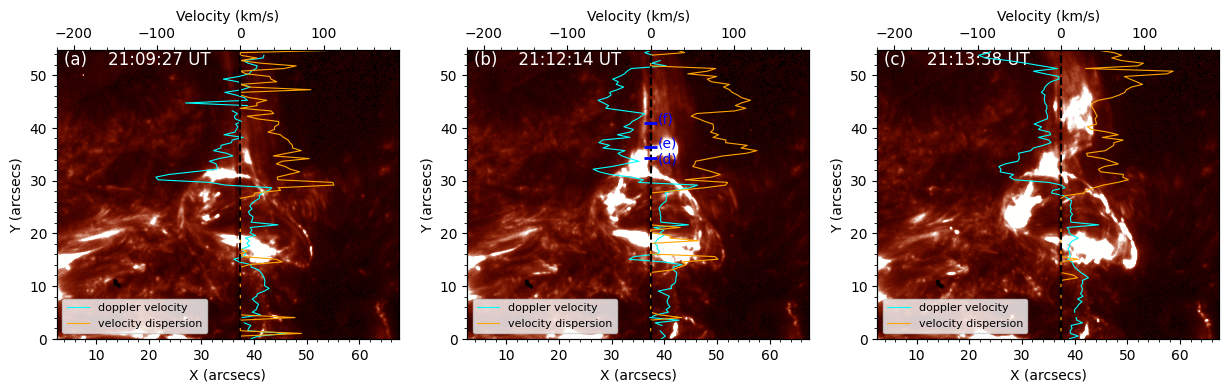

In [77]:
fig=plt.figure(figsize=(15,3.75))
gs=gridspec.GridSpec(1,3,wspace=0.2)
ax_all=[]
for i in range(3):
    ax=fig.add_subplot(gs[i])
    ax_all.append(ax)

list1=[799,807,811]
list2=[399,403,405]
list3=['(a)    21:09:27 UT','(b)    21:12:14 UT','(c)    21:13:38 UT']
for i in range(3):
    ax=ax_all[i]
    ax.imshow(all_sji_image[list1[i]][0][300:,:],cmap='irissji1400',vmin=0,vmax=20,
              origin='lower',extent=[0,422*0.166,0,330*0.166])
    ax.set_xlabel('X (arcsecs)')
    ax.set_ylabel('Y (arcsecs)')
    ax.minorticks_on()
    pos=ax.get_position()
    up_ax=ax.twiny()
    y_vals=np.linspace(0,330*0.166,110)
    kk=list2[i]
    cnt=kk-398
    up_ax.plot(doppler_vel_all[cnt,:],y_vals,color='cyan',linewidth=0.8,label='doppler velocity')
    up_ax.plot(sigma_vel_nonth[cnt,:],y_vals,color='orange',linewidth=0.8,label='velocity dispersion')
    up_ax.set_xlim(-220,190)
    up_ax.set_xlabel('Velocity (km/s)')
    up_ax.minorticks_on()
    up_ax.axvline(0,color='black',linestyle='--')
    if i==1:
        y_pos=np.array([69,73,82])*0.166*3
        up_ax.hlines(y_pos,-8,8,colors='blue',linewidth=2)
        up_ax.text(8,69*0.166*3-1,'(d)',color='blue',fontsize=10)
        up_ax.text(8,73*0.166*3,'(e)',color='blue',fontsize=10)
        up_ax.text(8,82*0.166*3,'(f)',color='blue',fontsize=10)
    #画双高斯拟合的散点图
    row=np.sum(vel_all[kk*2+1][:,4]==1)
    double_scatter=np.zeros((row,3))
    cnt=0
    ax.text(0.02,0.95,list3[i],color='white',transform=ax.transAxes,fontsize=12)
    up_ax.legend(loc='lower left',fontsize=8)
    #加图标
    
#plt.savefig(r'D:\Learning\PHD1st\magnetic_reconnecion\paper\fig2\three_iris_all.pdf',format='pdf',bbox_inches='tight', pad_inches=0.1)

In [69]:
print(69*0.166*3)

34.362


In [57]:
def gaussian(x, a, x0, sigma):
    return a * np.exp(-(x - x0)**2 / (2 * sigma**2))

def double_gaussian(x, a1, x1, sigma1, a2, x2, sigma2,c):
    return (a1 * np.exp(-(x - x1)**2 / (sigma1**2)) +
            a2 * np.exp(-(x - x2)**2 / (sigma2**2)) + c)

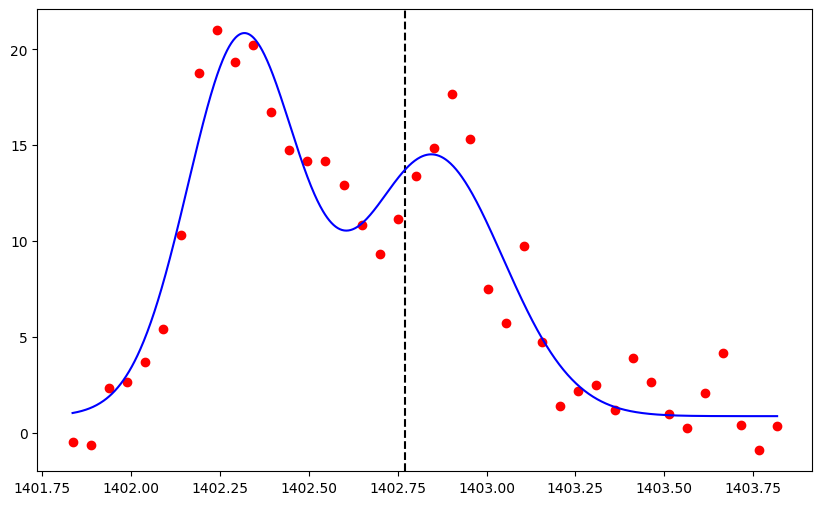

In [59]:
file_list=glob.glob(r'D:\Learning\PHD1st\magnetic_reconnecion\data\IRIS\iris_l2_20240618_163141_3602506433_raster\*.fits')
rsm=fits.open(file_list[403])
wave_x=np.arange(1398.28,1398.28+164*0.0508,0.0508)
i=73
wave_y=rsm[4].data[4,395+i*3:398+i*3,:].mean(axis=0)
a,b=70,110
x=wave_x[a:b]
y=wave_y[a:b]

#设置初始参数
a1_initial=max(y)-min(y)
sigma1_initial=0.1
x1_initial=1402.3
a2_initial=a1_initial
sigma2_initial=sigma1_initial
x2_initial=1402.77
c_initial=min(y)
initial_guess=[a1_initial,x1_initial,sigma1_initial,
               a2_initial,x2_initial,sigma2_initial,c_initial]

#双高斯拟合
popt,pcov=curve_fit(double_gaussian,x,y,p0=initial_guess,maxfev=5000)
#a1_fit,x1_fit,sigma1_fit,a2_fit,x2_fit,sigma2_fit,c_fit=popt
# 生成拟合曲线
x_fit = np.linspace(min(x), max(x), 1000)
y_fit = double_gaussian(x_fit, *popt)
plt.figure(figsize=(10, 6))
plt.scatter(wave_x[a:b], wave_y[a:b],color='red')
#plt.grid()
plt.axvline(x=1402.77,color='black',linestyle='--',linewidth=1.5)
plt.plot(x_fit, y_fit, label="Gaussian", color="blue")  # 画拟合曲线

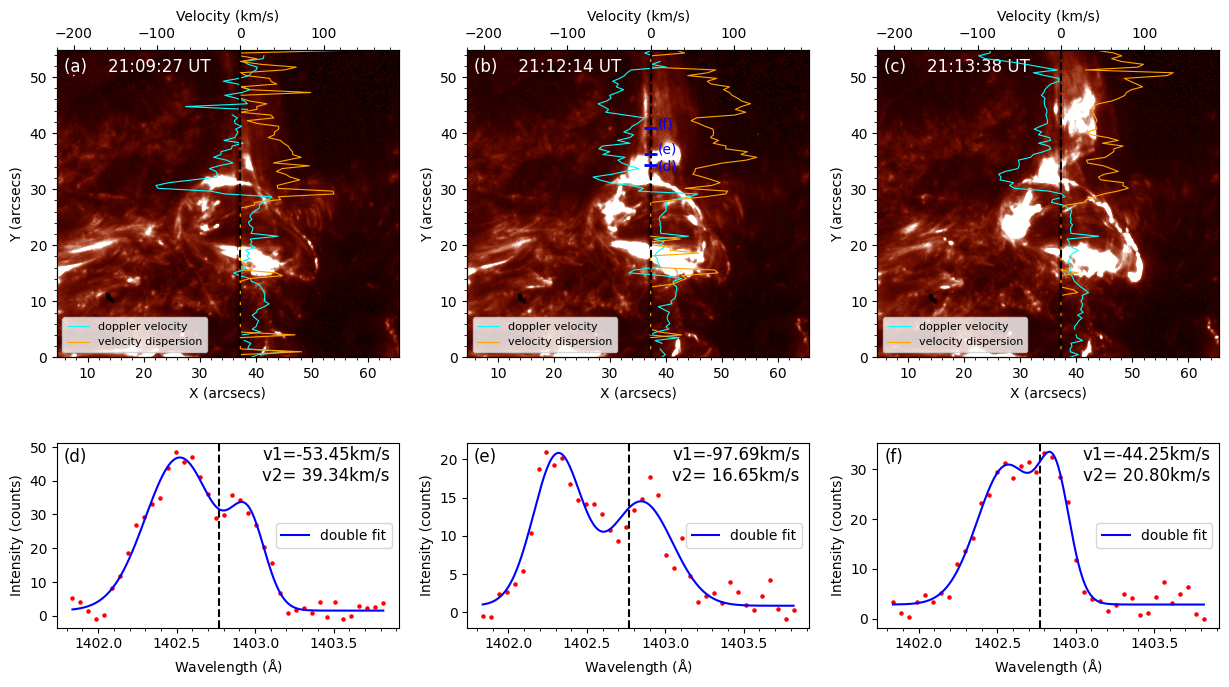

In [104]:
fig=plt.figure(figsize=(15,7.5))
gs=gridspec.GridSpec(2,1,height_ratios=[5,3],wspace=0.2,hspace=0.35)
gs_top=gridspec.GridSpecFromSubplotSpec(1,3,subplot_spec=gs[0])
ax_all=[]
for i in range(3):
    ax=fig.add_subplot(gs_top[i])
    ax_all.append(ax)

list1=[799,807,811]
list2=[399,403,405]
list3=['(a)    21:09:27 UT','(b)    21:12:14 UT','(c)    21:13:38 UT']
for i in range(3):
    ax=ax_all[i]
    ax.imshow(all_sji_image[list1[i]][0][300:,:],cmap='irissji1400',vmin=0,vmax=20,
              origin='lower',extent=[0,422*0.166,0,330*0.166])
    ax.set_xlabel('X (arcsecs)')
    ax.set_ylabel('Y (arcsecs)')
    ax.minorticks_on()
    pos=ax.get_position()
    up_ax=ax.twiny()
    y_vals=np.linspace(0,330*0.166,110)
    kk=list2[i]
    cnt=kk-398
    up_ax.plot(doppler_vel_all[cnt,:],y_vals,color='cyan',linewidth=0.8,label='doppler velocity')
    up_ax.plot(sigma_vel_nonth[cnt,:],y_vals,color='orange',linewidth=0.8,label='velocity dispersion')
    up_ax.set_xlim(-220,190)
    up_ax.set_xlabel('Velocity (km/s)')
    up_ax.minorticks_on()
    up_ax.axvline(0,color='black',linestyle='--')
    if i==1:
        y_pos=np.array([69,73,82])*0.166*3
        up_ax.hlines(y_pos,-8,8,colors='blue',linewidth=2)
        up_ax.text(8,69*0.166*3-1,'(d)',color='blue',fontsize=10)
        up_ax.text(8,73*0.166*3,'(e)',color='blue',fontsize=10)
        up_ax.text(8,82*0.166*3,'(f)',color='blue',fontsize=10)
    #画双高斯拟合的散点图
    row=np.sum(vel_all[kk*2+1][:,4]==1)
    double_scatter=np.zeros((row,3))
    cnt=0
    ax.text(0.02,0.93,list3[i],color='white',transform=ax.transAxes,fontsize=12)
    up_ax.legend(loc='lower left',fontsize=8)
    #加图标

#----------------------------------------------------------------------------
gs_bottom=gridspec.GridSpecFromSubplotSpec(1,3,subplot_spec=gs[1])
file_list=glob.glob(r'D:\Learning\PHD1st\magnetic_reconnecion\data\IRIS\iris_l2_20240618_163141_3602506433_raster\*.fits')
rsm=fits.open(file_list[403])
wave_x=np.arange(1398.28,1398.28+164*0.0508,0.0508)
cnt=0
ax2_all=[]
list4=['(d)','(e)','(f)']
for i in [69,73,82]:
    wave_y=rsm[4].data[4,395+i*3:398+i*3,:].mean(axis=0)
    a,b=70,110
    x=wave_x[a:b]
    y=wave_y[a:b]

    #设置初始参数
    a1_initial=max(y)-min(y)
    sigma1_initial=0.1
    x1_initial=1402.3
    a2_initial=a1_initial
    sigma2_initial=sigma1_initial
    x2_initial=1402.77
    c_initial=min(y)
    initial_guess=[a1_initial,x1_initial,sigma1_initial,
                a2_initial,x2_initial,sigma2_initial,c_initial]

    #双高斯拟合
    popt,pcov=curve_fit(double_gaussian,x,y,p0=initial_guess,maxfev=5000)
    a1_fit,x1_fit,sigma1_fit,a2_fit,x2_fit,sigma2_fit,c_fit=popt

    
    # 生成拟合曲线
    x_fit = np.linspace(min(x), max(x), 1000)
    y_fit = double_gaussian(x_fit, *popt)

    ax=fig.add_subplot(gs_bottom[cnt])
    ax2_all.append(ax)
    ax.scatter(x,y,color='red',s=5)
    ax.axvline(x=1402.77,color='black',linestyle='--',linewidth=1.5)
    ax.plot(x_fit, y_fit, label="double fit", color="blue")  # 画拟合曲线
    ax.text(0.02,0.9,list4[cnt],color='black',transform=ax.transAxes,fontsize=12)
    ax.set_xlabel('Wavelength $(\mathrm{\AA})$')
    ax.set_ylabel('Intensity (counts)')
    ax.legend(loc='center right')


    v1=(x1_fit-1402.77)/1402.77*299792.458
    v2=(x2_fit-1402.77)/1402.77*299792.458
    ax.text(0.6,0.8,'v1='+f'{v1:.2f}'+'km/s\n'+'v2= '+f'{v2:.2f}'+'km/s',
            transform=ax.transAxes,fontsize=12)
    
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())  # 给 x 轴加小刻度
    ax.yaxis.set_minor_locator(ticker.NullLocator())    
    cnt=cnt+1


plt.savefig(r'D:\Learning\PHD1st\magnetic_reconnecion\paper\fig2\iris.pdf',format='pdf',bbox_inches='tight', pad_inches=0.1)

DEM 三个不同位置的EM T随时间变化图

In [2]:
time_list=glob.glob(r'D:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\131\\'+'*.fits')
file_list=glob.glob(r'D:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\DEM2\\'+'*.sav')
avg_temp=np.zeros((58,3))
avg_em=np.zeros((58,3))
for i in range(58):
    datas=readsav(file_list[i*2+1])
    result=datas['result']
    smap_temp=result['SMAP_TEMP'][0]
    smap_em=result['SMAP_EM'][0]

    avg_temp[i,0]=np.mean(smap_temp[138:148,102:112])
    avg_temp[i,1]=np.mean(smap_temp[140:150,142:152])
    avg_temp[i,2]=np.mean(smap_temp[80:90,15:25])
    avg_em[i,0]=np.mean(smap_em[138:148,102:112])
    avg_em[i,1]=np.mean(smap_em[140:150,142:152])
    avg_em[i,2]=np.mean(smap_em[80:90,15:25])


In [3]:
data=np.load(r'D:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\fit_points.npz')
slice=np.load(r'D:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\result_matrix.npy')
a=data['fit_points']
b=data['fit_points2']
c=data['fit_points3']

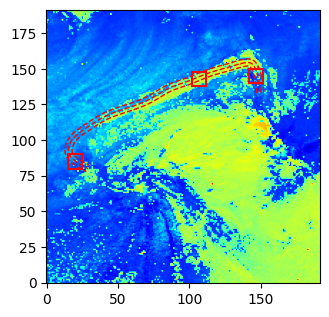

In [115]:
fig=plt.figure(figsize=(12,10))
ax22=fig.add_subplot(gs_top[1])
datas=readsav(file_list[56])
result=datas['result']
dem_out=result['DEM_OUT'][0]
smap_temp=result['SMAP_TEMP'][0]
smap_em=result['SMAP_EM'][0]
im=ax22.imshow(np.log10(smap_temp),vmin=6.0,vmax=7.3,cmap='jet',origin='lower')

left_bottom1=(102,138)
rect1=Rectangle(left_bottom1,10,10,edgecolor='red',facecolor='none',linewidth=1.5)
ax22.plot(b[:,1]/2,b[:,0]/2,linestyle='--',color='red',linewidth=1)
ax22.plot(a[:,1]/2,a[:,0]/2,linestyle='--',color='red',linewidth=1)
ax22.plot(c[:,1]/2,c[:,0]/2,linestyle='--',color='red',linewidth=1)
ax22.add_patch(rect1)

left_bottom2=(142,140)
rect2=Rectangle(left_bottom2,10,10,edgecolor='red',facecolor='none',linewidth=1.5)
left_bottom3=(15,80)
rect3=Rectangle(left_bottom3,10,10,edgecolor='red',facecolor='none',linewidth=1.5)
ax22.add_patch(rect2)
ax22.add_patch(rect3)

Text(0.5, 1.0, 'Average Temperature and EM in Rectangular Region')

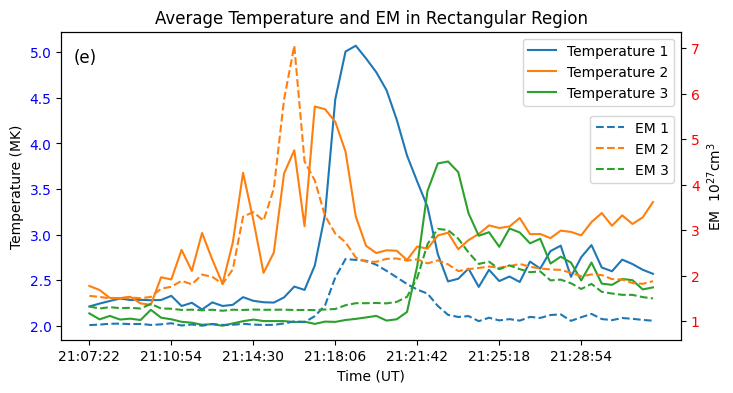

In [20]:
fig,ax1=plt.subplots(figsize=(8,4))
#ax1=fig.add_subplot()
ax1.plot((avg_temp[:56,0])/1e6,label='Temperature 1')
ax1.plot((avg_temp[:56,1])/1e6,label='Temperature 2')
ax1.plot((avg_temp[:56,2])/1e6,label='Temperature 3')
ax1.set_xlabel('Time (UT)')
ax1.set_ylabel('Temperature (MK)')
labels_arr=[]
#设置xticks
for i in range(0,56,9):
    labels_arr.append(file_list[i*2+1][-12:-4].replace("_",":"))
ax1.set_xticks(ticks=np.arange(0,56,8),labels=labels_arr)
ax1.tick_params(axis='y',labelcolor='b')
ax2=ax1.twinx()
ax2.plot(avg_em[:56,0]/1e27,label='EM 1',linestyle='--')
ax2.plot(avg_em[:56,1]/1e27,label='EM 2',linestyle='--')
ax2.plot(avg_em[:56,2]/1e27,label='EM 3',linestyle='--')
ax2.set_ylabel('EM  '+ r'$10^{27} \text{cm}^3$')
ax2.tick_params(axis='y',labelcolor='r')
ax1.legend(loc='upper right')
ax2.legend(loc='upper right',bbox_to_anchor=(1.0,0.75))
# 显示图形
ax1.text(0.02,0.9,'(e)',color='black',transform=ax1.transAxes,fontsize=12)
plt.title('Average Temperature and EM in Rectangular Region',size=12)

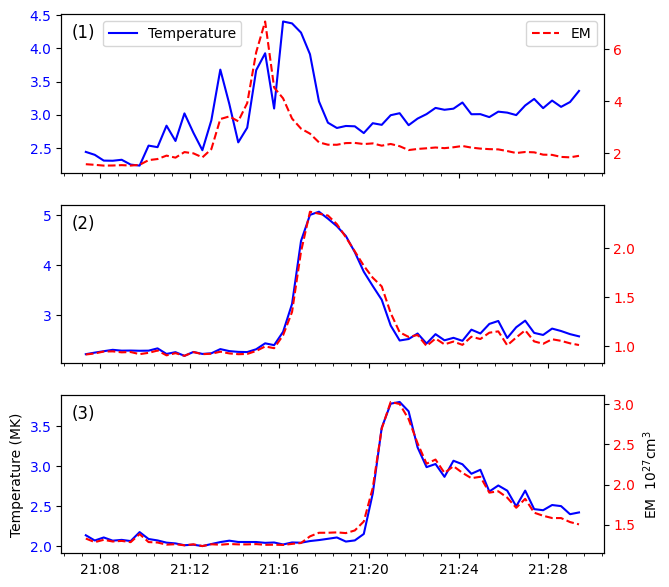

In [47]:
#ax2实际上对应avg_temp[:,0]是起点区域，时间最早所以给他放在最上面
fig,(ax2,ax1,ax3)=plt.subplots(3,1,figsize=(7,7),sharex=True,
                               gridspec_kw={'height_ratios': [1, 1, 1]})

ax1.plot((avg_temp[:56,0])/1e6,label='Temperature',color='blue')
#ax1.set_ylabel('Temperature (MK)')
ax1.tick_params(axis='y',labelcolor='blue')
ax1.text(0.02,0.85,'(2)',color='black',transform=ax1.transAxes,fontsize=12)
ax11=ax1.twinx()
ax11.plot(avg_em[:56,0]/1e27,label='EM',linestyle='--',color='red')
#ax11.set_ylabel('EM  '+ r'$10^{27} \text{cm}^3$')
ax11.tick_params(axis='y',labelcolor='red')
coor_x=np.zeros(6)
for i in range(len(coor_x)):
    coor_x[i]=(i*240+38)/24
label_x=['21:08','21:12','21:16','21:20','21:24','21:28']
ax1.set_xticks(ticks=coor_x,labels=label_x)
ax1.xaxis.set_minor_locator(ticker.AutoMinorLocator())  # 给 x 轴加小刻度
ax1.yaxis.set_minor_locator(ticker.NullLocator())

ax2.plot((avg_temp[:56,1])/1e6,label='Temperature',color='blue')
#ax2.set_ylabel('Temperature (MK)')
ax2.tick_params(axis='y',labelcolor='blue')
ax2.text(0.02,0.85,'(1)',color='black',transform=ax2.transAxes,fontsize=12)

ax22=ax2.twinx()
ax22.plot(avg_em[:56,1]/1e27,label='EM',linestyle='--',color='red')
#ax22.set_ylabel('EM  '+ r'$10^{27} \text{cm}^3$')
ax22.tick_params(axis='y',labelcolor='red')
ax2.legend(loc='upper left',bbox_to_anchor=(0.065,1))
ax22.legend(loc='upper right')

ax3.plot((avg_temp[:56,2])/1e6,label='Temperature 3',color='blue')
ax3.set_ylabel('Temperature (MK)')
ax3.tick_params(axis='y',labelcolor='blue')
ax3.text(0.02,0.85,'(3)',color='black',transform=ax3.transAxes,fontsize=12)
ax33=ax3.twinx()
ax33.plot(avg_em[:56,2]/1e27,label='EM 3',linestyle='--',color='red')
ax33.set_ylabel('EM  '+ r'$10^{27} \text{cm}^3$')
ax33.tick_params(axis='y',labelcolor='red')

plt.savefig(r'D:\Learning\PHD1st\magnetic_reconnecion\paper\fig2\T_DEM_time.pdf',format='pdf',bbox_inches='tight', pad_inches=0.1)
